# Figure 2

## Define data loading and plotting functions


In [1]:
"""
Geometry-distribution figure with a distinct colour per panel.
Panels: (a) Characteristic size b, (b) Cross-sectional area A, (c) Gauge length L.

Requirements: pandas, numpy, matplotlib
Data:  Creep_Properties_Dataset.xlsx
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# DATA LOADING
# ----------------------------------------------------------------------
def load_data(path, sheet="Data", header=1):
    df = pd.read_excel(path, sheet_name=sheet, header=header)
    d = pd.DataFrame({
        "alloy": df.iloc[:, 2].astype(str).str.strip(),
        "notch": df.iloc[:, 48].astype(str).str.strip(),
        "b":     pd.to_numeric(df.iloc[:, 46], errors="coerce"),
        "A":     pd.to_numeric(df.iloc[:, 50], errors="coerce"),
        "L":     pd.to_numeric(df.iloc[:, 45], errors="coerce"),   # Gauge length (mm)
        "LD":    pd.to_numeric(df.iloc[:, 49], errors="coerce"),
        "sigma": pd.to_numeric(df.iloc[:, 53], errors="coerce"),
        "temp":  pd.to_numeric(df.iloc[:, 54], errors="coerce"),
        "tR":    pd.to_numeric(df.iloc[:, 55], errors="coerce"),
    })
    m = ((d.notch == "unnotched") & (d.sigma > 0) & (d.tR > 0) &
         (d.temp > 0) & (d.b > 0) & (d.A > 0) & (d.LD > 0))
    return d[m].dropna(subset=["b", "A", "LD"]).reset_index(drop=True)


# ----------------------------------------------------------------------
# FIGURE: geometry distribution histograms – one colour per panel
# ----------------------------------------------------------------------
def fig_distributions_colored(s_all):
    LABEL_SIZE = 17   # axis label font size
    TICK_SIZE  = 15   # axis tick font size
    TITLE_SIZE = 17   # subplot title font size

    plt.rcParams.update({
        "font.family": "serif",
        "font.size":   TICK_SIZE,
        "axes.labelsize":  LABEL_SIZE,
        "axes.titlesize":  TITLE_SIZE,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": TICK_SIZE,
    })

    COLORS = {
        "b": "#2e6da4",   # steel blue   – characteristic size
        "A": "#c0392b",   # brick red    – cross-sectional area
        "L": "#27a05b",   # forest green – gauge length
    }
    EDGE = "white"

    def despine(a):
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.5), constrained_layout=True)

    # (a) Characteristic size b
    ax[0].hist(
        s_all.b,
        bins=np.arange(0.5, 15.5, 1.0),
        color=COLORS["b"], edgecolor=EDGE, linewidth=0.8, rwidth=0.9,
    )
    ax[0].set_xlabel("Characteristic size  $b$  (mm)")
    ax[0].set_title("(a) Characteristic size", fontweight="bold")

    # (b) Cross-sectional area A
    ax[1].hist(
        s_all.A,
        bins=np.arange(0, 185, 10),
        color=COLORS["A"], edgecolor=EDGE, linewidth=0.8, rwidth=0.95,
    )
    ax[1].set_xlabel("Cross-sectional area  $A$  (mm$^2$)")
    ax[1].set_title("(b) Cross-sectional area", fontweight="bold")

    # (c) Gauge length L
    L_clean = s_all.L.dropna()
    L_clean = L_clean[L_clean > 0]
    L_max   = L_clean.max()
    step    = 5 if L_max <= 150 else 10
    bins_L  = np.arange(0, L_max + step, step)
    ax[2].hist(
        L_clean,
        bins=bins_L,
        color=COLORS["L"], edgecolor=EDGE, linewidth=0.8, rwidth=0.9,
    )
    ax[2].set_xlabel("Gauge length  $L$  (mm)")
    ax[2].set_title("(c) Gauge length", fontweight="bold")

    for a in ax:
        a.set_ylabel("Number of records")
        a.grid(axis="y", alpha=0.15)
        despine(a)

    plt.show()


## Generate Figure 2


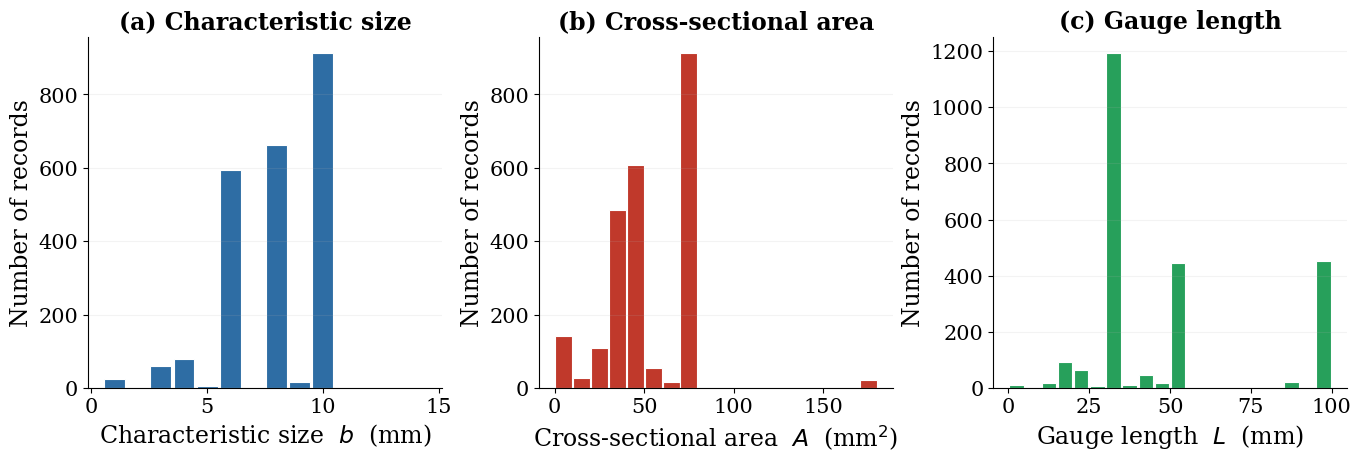

In [2]:
# ----------------------------------------------------------------------
# RUN
# ----------------------------------------------------------------------
PATH = os.path.join("..", "Dataset", "Creep_Properties_Dataset.xlsx")
data = load_data(PATH)
fig_distributions_colored(data)
